# DC2 Flow Matching Results

## Setup & Imports

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from einops import rearrange
from hydra import compose, initialize
from hydra.utils import instantiate
from scipy.stats import kendalltau, spearmanr

plt.rcParams["font.family"] = "serif"

import lightning as L
from lightning.pytorch.utilities import move_data_to_device

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
cpu_device = torch.device("cpu")

## Load FM Model

In [2]:
fm_ckpt = "/data/scratch/twhit/checkpoints/trained_fm_dc2.ckpt"

with initialize(config_path="../", version_base=None):
    fm_cfg = compose(
        "config_train_flowmatching",
        {
            "train.pretrained_weights=" + fm_ckpt,
        },
    )

seed = L.seed_everything(fm_cfg.train.seed)

Seed set to 42


In [3]:
data_source = instantiate(fm_cfg.train.data_source)
data_source.setup("test")
test_dl = data_source.test_dataloader()
num_batches = len(test_dl)
print(f"Number of test batches: {num_batches}")

Number of test batches: 40


In [4]:
fm_encoder = instantiate(fm_cfg.encoder).to(device)
fm_state_dict = torch.load(fm_cfg.train.pretrained_weights, map_location=device)["state_dict"]
fm_encoder.load_state_dict(fm_state_dict)
fm_encoder = fm_encoder.eval()

## FM Sampling Loop

1000 samples per image, 50 ODE time steps, midpoint method.

In [5]:
torch.manual_seed(0)

num_samples_per_image = 1000
num_time_steps = 50
num_bins = 4
scale_factor = 100.0

all_z_cpu = []
all_z1_cpu = []

ra = torch.zeros(len(test_dl), 8, 8, num_bins, device=device)
dec = torch.zeros(len(test_dl), 8, 8, num_bins, device=device)

for batch_idx, batch_data in enumerate(test_dl):
    print(f"Processing batch {batch_idx + 1}/{num_batches}")

    batch = move_data_to_device(batch_data, device)

    x_list = [inorm.get_input_tensor(batch) for inorm in fm_encoder.image_normalizers]
    x = torch.cat(x_list, dim=2)

    x_embedding = fm_encoder.image_encoder(x)

    ra[batch_idx] = batch["tile_catalog"]["ra"].squeeze()
    dec[batch_idx] = batch["tile_catalog"]["dec"].squeeze()

    shear1 = scale_factor * rearrange(batch["tile_catalog"]["shear_1"], "b h w r -> b r h w")
    shear2 = scale_factor * rearrange(batch["tile_catalog"]["shear_2"], "b h w r -> b r h w")
    convergence = scale_factor * rearrange(batch["tile_catalog"]["convergence"], "b h w r -> b r h w")
    z1 = torch.cat([shear1, shear2, convergence], dim=1)

    # Free memory before sampling
    fm_encoder.image_encoder = fm_encoder.image_encoder.to(cpu_device)
    x = x.to(cpu_device)
    batch = move_data_to_device(batch, cpu_device)
    del x_list
    shear1, shear2, convergence = shear1.to(cpu_device), shear2.to(cpu_device), convergence.to(cpu_device)
    torch.cuda.empty_cache()

    t = torch.linspace(0.0, 1.0, num_time_steps + 1, device=device).view(-1, 1).expand(-1, num_samples_per_image).unsqueeze(-1)
    # t shape: (num_time_steps+1, num_samples, 1)
    x_embedding_expanded = x_embedding.expand(num_samples_per_image, -1, z1.shape[-2], z1.shape[-1])
    z = torch.randn(num_samples_per_image, z1.shape[1], z1.shape[2], z1.shape[3], device=device)

    for i in range(num_time_steps):
        with torch.no_grad():
            z = fm_encoder.sample_path(z, x_embedding_expanded, t[i], t[i + 1], method="midpoint")

    # Divide by scale_factor (manual sampling doesn't do this automatically)
    all_z_cpu.append((z / scale_factor).to(cpu_device))
    all_z1_cpu.append((z1 / scale_factor).to(cpu_device))

    del z, x_embedding_expanded, t, x_embedding, z1
    fm_encoder.image_encoder = fm_encoder.image_encoder.to(device)
    torch.cuda.empty_cache()

    print(f"Batch {batch_idx + 1} complete.")

Processing batch 1/40
Batch 1 complete.
Processing batch 2/40
Batch 2 complete.
Processing batch 3/40
Batch 3 complete.
Processing batch 4/40
Batch 4 complete.
Processing batch 5/40
Batch 5 complete.
Processing batch 6/40
Batch 6 complete.
Processing batch 7/40
Batch 7 complete.
Processing batch 8/40
Batch 8 complete.
Processing batch 9/40
Batch 9 complete.
Processing batch 10/40
Batch 10 complete.
Processing batch 11/40
Batch 11 complete.
Processing batch 12/40
Batch 12 complete.
Processing batch 13/40
Batch 13 complete.
Processing batch 14/40
Batch 14 complete.
Processing batch 15/40
Batch 15 complete.
Processing batch 16/40
Batch 16 complete.
Processing batch 17/40
Batch 17 complete.
Processing batch 18/40
Batch 18 complete.
Processing batch 19/40
Batch 19 complete.
Processing batch 20/40
Batch 20 complete.
Processing batch 21/40
Batch 21 complete.
Processing batch 22/40
Batch 22 complete.
Processing batch 23/40
Batch 23 complete.
Processing batch 24/40
Batch 24 complete.
Processing

In [6]:
# Stack: fm_z shape (num_batches, num_samples, z_dim, 8, 8)
# fm_z1 shape (num_batches, 1, z_dim, 8, 8)
fm_z = torch.stack(all_z_cpu, dim=0)
fm_z1 = torch.cat(all_z1_cpu, dim=0).unsqueeze(1)
ra = ra.cpu()
dec = dec.cpu()

del all_z_cpu, all_z1_cpu

fm_encoder.image_encoder = fm_encoder.image_encoder.to(cpu_device)
torch.cuda.empty_cache()

print(f"fm_z shape: {fm_z.shape}")
print(f"fm_z1 shape: {fm_z1.shape}")

fm_z shape: torch.Size([40, 1000, 12, 8, 8])
fm_z1 shape: torch.Size([40, 1, 12, 8, 8])


Extract per-variable tensors from FM results:

In [7]:
# fm_z: (num_batches, num_samples, z_dim, 8, 8) -> rearrange to (num_batches, num_samples, 8, 8, num_bins)
fm_shear1_pred = rearrange(fm_z[:, :, 0:num_bins], "b n d h w -> b n h w d")
fm_shear2_pred = rearrange(fm_z[:, :, num_bins:2*num_bins], "b n d h w -> b n h w d")
fm_convergence_pred = rearrange(fm_z[:, :, 2*num_bins:3*num_bins], "b n d h w -> b n h w d")

# fm_z1: (num_batches, 1, z_dim, 8, 8) -> (num_batches, 8, 8, num_bins)
fm_shear1_true = rearrange(fm_z1.squeeze(1)[:, 0:num_bins], "b d h w -> b h w d")
fm_shear2_true = rearrange(fm_z1.squeeze(1)[:, num_bins:2*num_bins], "b d h w -> b h w d")
fm_convergence_true = rearrange(fm_z1.squeeze(1)[:, 2*num_bins:3*num_bins], "b d h w -> b h w d")

# FM posterior mean
fm_shear1_mean = fm_shear1_pred.mean(1)
fm_shear2_mean = fm_shear2_pred.mean(1)
fm_convergence_mean = fm_convergence_pred.mean(1)

## Load NPE Model

In [8]:
npe_ckpt = "/data/scratch/twhit/checkpoints/trained_encoder_dc2.ckpt"

with initialize(config_path="../", version_base=None):
    npe_cfg = compose(
        "config_train_npe",
        {
            "train.pretrained_weights=" + npe_ckpt,
        },
    )

seed = L.seed_everything(npe_cfg.train.seed)

Seed set to 123123


In [9]:
npe_encoder = instantiate(npe_cfg.encoder).to(device)
npe_state_dict = torch.load(npe_cfg.train.pretrained_weights, map_location=device)["state_dict"]
npe_encoder.load_state_dict(npe_state_dict, strict=False)
npe_encoder = npe_encoder.eval()

### NPE Inference Loop

Get posterior mean, std, and 3 samples per image.

In [10]:
torch.manual_seed(0)

num_tiles_per_side = 8
num_npe_samples = 3

npe_shear1_true = torch.zeros(len(test_dl), num_tiles_per_side, num_tiles_per_side, num_bins, device=device)
npe_shear1_pred = torch.zeros(len(test_dl), num_tiles_per_side, num_tiles_per_side, num_bins, device=device)
npe_shear1_std = torch.zeros(len(test_dl), num_tiles_per_side, num_tiles_per_side, num_bins, device=device)
npe_shear2_true = torch.zeros(len(test_dl), num_tiles_per_side, num_tiles_per_side, num_bins, device=device)
npe_shear2_pred = torch.zeros(len(test_dl), num_tiles_per_side, num_tiles_per_side, num_bins, device=device)
npe_shear2_std = torch.zeros(len(test_dl), num_tiles_per_side, num_tiles_per_side, num_bins, device=device)
npe_convergence_true = torch.zeros(len(test_dl), num_tiles_per_side, num_tiles_per_side, num_bins, device=device)
npe_convergence_pred = torch.zeros(len(test_dl), num_tiles_per_side, num_tiles_per_side, num_bins, device=device)
npe_convergence_std = torch.zeros(len(test_dl), num_tiles_per_side, num_tiles_per_side, num_bins, device=device)

npe_convergence_samples = torch.zeros(len(test_dl), num_tiles_per_side, num_tiles_per_side, num_bins, num_npe_samples, device=device)
npe_shear1_samples = torch.zeros(len(test_dl), num_tiles_per_side, num_tiles_per_side, num_bins, num_npe_samples, device=device)
npe_shear2_samples = torch.zeros(len(test_dl), num_tiles_per_side, num_tiles_per_side, num_bins, num_npe_samples, device=device)

i = -1
for b in test_dl:
    i += 1
    print(i)
    batch = move_data_to_device(b, device)

    npe_shear1_true[i] = batch["tile_catalog"]["shear_1"].squeeze()
    npe_shear2_true[i] = batch["tile_catalog"]["shear_2"].squeeze()
    npe_convergence_true[i] = batch["tile_catalog"]["convergence"].squeeze()

    with torch.no_grad():
        input_lst = [inorm.get_input_tensor(batch) for inorm in npe_encoder.image_normalizers]
        inputs = torch.cat(input_lst, dim=2)

        x_cat_marginal = npe_encoder.net(inputs).squeeze(0)
        npe_shear1_pred[i] = x_cat_marginal[:, :, 0:num_bins].squeeze()
        npe_shear1_std[i] = x_cat_marginal[:, :, num_bins:(2 * num_bins)].exp().sqrt().squeeze()
        npe_shear2_pred[i] = x_cat_marginal[:, :, (2 * num_bins):(3 * num_bins)].squeeze()
        npe_shear2_std[i] = x_cat_marginal[:, :, (3 * num_bins):(4 * num_bins)].exp().sqrt().squeeze()
        npe_convergence_pred[i] = x_cat_marginal[:, :, (4 * num_bins):(5 * num_bins)].squeeze()
        npe_convergence_std[i] = x_cat_marginal[:, :, (5 * num_bins):(6 * num_bins)].exp().sqrt().squeeze()

        npe_convergence_samples[i] = rearrange(
            torch.distributions.Normal(npe_convergence_pred[i], npe_convergence_std[i]).sample([num_npe_samples]),
            "s h w b -> h w b s",
        )
        npe_shear1_samples[i] = rearrange(
            torch.distributions.Normal(npe_shear1_pred[i], npe_shear1_std[i]).sample([num_npe_samples]),
            "s h w b -> h w b s",
        )
        npe_shear2_samples[i] = rearrange(
            torch.distributions.Normal(npe_shear2_pred[i], npe_shear2_std[i]).sample([num_npe_samples]),
            "s h w b -> h w b s",
        )

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39


## Posterior Mean Maps

Sort all 40 test images into a spatial grid and plot convergence maps: NPE + FM side by side.

In [11]:
# Sort images into spatial grid (8 rows x 5 cols = 40 images)
ra_mean = ra.mean([1, 2, 3])
dec_mean = dec.mean([1, 2, 3])

dec_sort_idx = torch.argsort(dec_mean)
dec_bins_idx = dec_sort_idx.view(8, 5)

sorted_indices = torch.zeros_like(dec_bins_idx)
for i in range(8):
    ra_in_row = ra_mean[dec_bins_idx[i]]
    ra_sort_idx = torch.argsort(-ra_in_row)
    sorted_indices[i] = dec_bins_idx[i][ra_sort_idx]

idx = sorted_indices.flatten()

In [12]:
# Rearrange NPE data into spatial grid
ra_sorted = rearrange(ra[idx].view(8, 5, 8, 8, num_bins), "h w nh nw b -> (h nh) (w nw) b")
dec_sorted = rearrange(dec[idx].view(8, 5, 8, 8, num_bins), "h w nh nw b -> (h nh) (w nw) b")

npe_conv_true_sorted = rearrange(npe_convergence_true[idx].cpu().view(8, 5, 8, 8, num_bins), "h w nh nw b -> (h nh) (w nw) b")
npe_conv_pred_sorted = rearrange(npe_convergence_pred[idx].cpu().view(8, 5, 8, 8, num_bins), "h w nh nw b -> (h nh) (w nw) b")
npe_conv_samples_sorted = rearrange(
    npe_convergence_samples[idx].cpu().view(8, 5, 8, 8, num_bins, num_npe_samples),
    "h w nh nw b ns -> (h nh) (w nw) b ns",
)

# Rearrange FM data into spatial grid
fm_conv_true_sorted = rearrange(fm_convergence_true[idx].view(8, 5, 8, 8, num_bins), "h w nh nw b -> (h nh) (w nw) b")
fm_conv_mean_sorted = rearrange(fm_convergence_mean[idx].view(8, 5, 8, 8, num_bins), "h w nh nw b -> (h nh) (w nw) b")
fm_conv_pred_sorted = rearrange(
    fm_convergence_pred[idx].view(8, 5, num_samples_per_image, 8, 8, num_bins),
    "h w ns nh nw b -> (h nh) (w nw) b ns",
)

extent = [
    ra_sorted.max().cpu().item(),
    ra_sorted.min().cpu().item(),
    dec_sorted.min().cpu().item(),
    dec_sorted.max().cpu().item(),
]

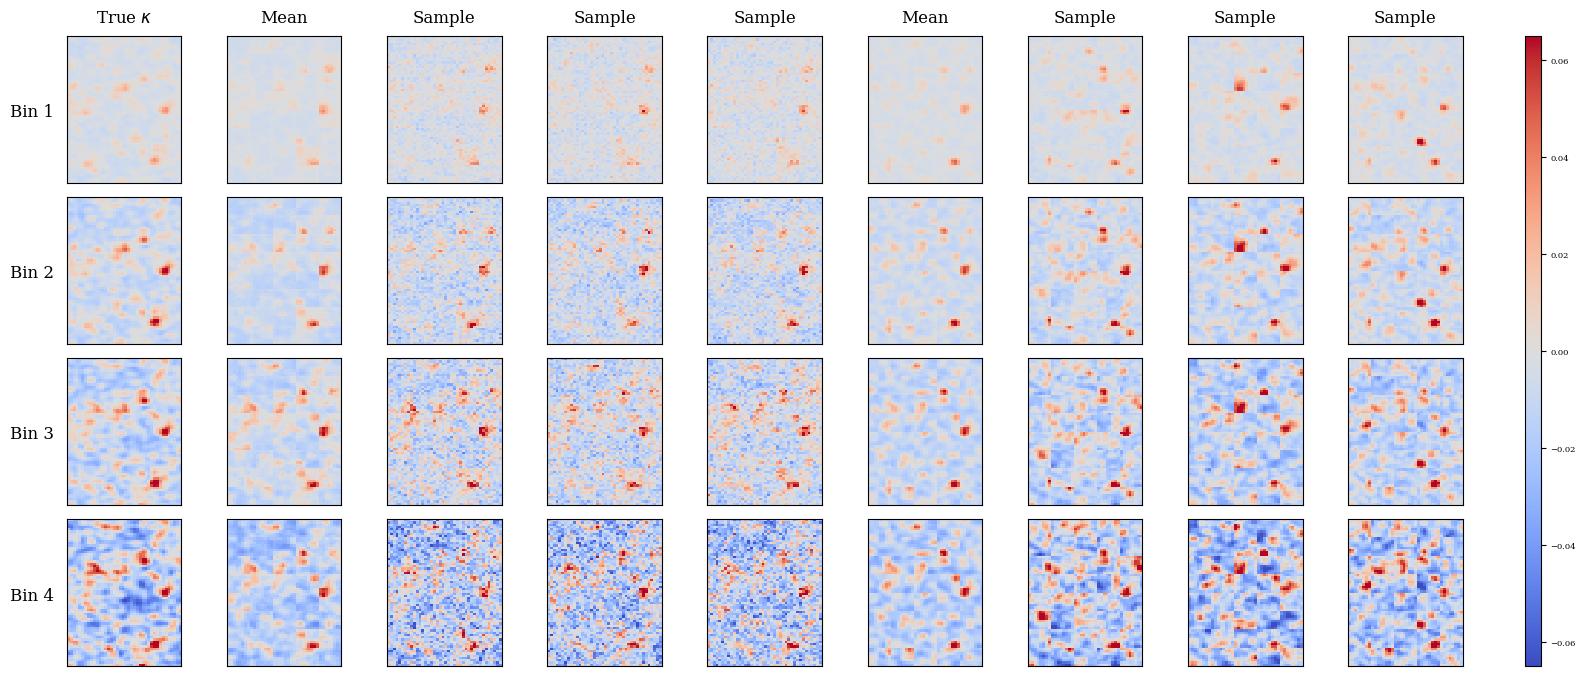

In [13]:
vmin = -0.065
vmax = 0.065
fontsize = 12
ticklabelsize = 6
interpolation = "none"

torch.manual_seed(42)
fm_sample_idx = torch.randint(0, num_samples_per_image, [3])

fig, ax = plt.subplots(num_bins, 9, figsize=(16, 7))

for b in range(num_bins):
    # True
    _ = ax[b, 0].imshow(npe_conv_true_sorted[..., b].cpu(), extent=extent, origin="lower",
                        interpolation=interpolation, vmin=vmin, vmax=vmax, cmap="coolwarm")
    # NPE posterior mean
    _ = ax[b, 1].imshow(npe_conv_pred_sorted[..., b].cpu(), extent=extent, origin="lower",
                        interpolation=interpolation, vmin=vmin, vmax=vmax, cmap="coolwarm")
    # NPE samples
    for s in range(3):
        _ = ax[b, 2 + s].imshow(npe_conv_samples_sorted[..., b, s].cpu(), extent=extent, origin="lower",
                                interpolation=interpolation, vmin=vmin, vmax=vmax, cmap="coolwarm")
    # FM posterior mean
    _ = ax[b, 5].imshow(fm_conv_mean_sorted[..., b].cpu(), extent=extent, origin="lower",
                        interpolation=interpolation, vmin=vmin, vmax=vmax, cmap="coolwarm")
    # FM samples
    for s in range(3):
        tmp = ax[b, 6 + s].imshow(fm_conv_pred_sorted[..., b, fm_sample_idx[s]].cpu(), extent=extent, origin="lower",
                                  interpolation=interpolation, vmin=vmin, vmax=vmax, cmap="coolwarm")

_ = ax[0, 0].set_title(r"True $\kappa$", fontsize=fontsize, pad=10)
_ = ax[0, 1].set_title("Mean", fontsize=fontsize, pad=10)
_ = ax[0, 2].set_title("Sample", fontsize=fontsize, pad=10)
_ = ax[0, 3].set_title("Sample", fontsize=fontsize, pad=10)
_ = ax[0, 4].set_title("Sample", fontsize=fontsize, pad=10)
_ = ax[0, 5].set_title("Mean", fontsize=fontsize, pad=10)
_ = ax[0, 6].set_title("Sample", fontsize=fontsize, pad=10)
_ = ax[0, 7].set_title("Sample", fontsize=fontsize, pad=10)
_ = ax[0, 8].set_title("Sample", fontsize=fontsize, pad=10)

for b in range(num_bins):
    _ = ax[b, 0].set_ylabel(f"Bin {b + 1}", fontsize=fontsize, rotation=0, labelpad=25, y=0.425)

fig.subplots_adjust(right=0.95)
cbar_ax = fig.add_axes([0.975, 0.05, 0.01, 0.9])
cbar_ax.tick_params(labelsize=ticklabelsize)
fig.colorbar(tmp, cax=cbar_ax)

fig.subplots_adjust(left=0.05, right=0.95, top=0.95, bottom=0.05, wspace=0.01, hspace=0.1)

for a in ax.flat:
    a.set_xticks([])
    a.set_yticks([])

fig.savefig("figures/posteriormeanconvergencemaps_npe_fm.png", dpi=600, transparent=True, bbox_inches="tight", pad_inches=0)

## Metrics (RMSE, Pearson, Spearman, Kendall)

In [14]:
for b in range(num_bins):
    s1_true = fm_shear1_true[..., b].flatten().cpu().numpy()
    s1_pred = fm_shear1_mean[..., b].flatten().cpu().numpy()
    s2_true = fm_shear2_true[..., b].flatten().cpu().numpy()
    s2_pred = fm_shear2_mean[..., b].flatten().cpu().numpy()
    k_true = fm_convergence_true[..., b].flatten().cpu().numpy()
    k_pred = fm_convergence_mean[..., b].flatten().cpu().numpy()

    print(f"Redshift bin {b + 1}:")
    print(f"  Shear 1 RMSE = {np.sqrt(((s1_true - s1_pred) ** 2).mean()):.6f}")
    print(f"  Shear 2 RMSE = {np.sqrt(((s2_true - s2_pred) ** 2).mean()):.6f}")
    print(f"  Convergence RMSE = {np.sqrt(((k_true - k_pred) ** 2).mean()):.6f}")
    print(f"  Shear 1 Pearson = {np.corrcoef(s1_true, s1_pred)[1, 0]:.4f}")
    print(f"  Shear 2 Pearson = {np.corrcoef(s2_true, s2_pred)[1, 0]:.4f}")
    print(f"  Convergence Pearson = {np.corrcoef(k_true, k_pred)[1, 0]:.4f}")
    print(f"  Shear 1 Spearman = {spearmanr(s1_true, s1_pred)[0]:.4f}")
    print(f"  Shear 2 Spearman = {spearmanr(s2_true, s2_pred)[0]:.4f}")
    print(f"  Convergence Spearman = {spearmanr(k_true, k_pred)[0]:.4f}")
    print(f"  Shear 1 Kendall = {kendalltau(s1_true, s1_pred)[0]:.4f}")
    print(f"  Shear 2 Kendall = {kendalltau(s2_true, s2_pred)[0]:.4f}")
    print(f"  Convergence Kendall = {kendalltau(k_true, k_pred)[0]:.4f}")
    print()

Redshift bin 1:
  Shear 1 RMSE = 0.004605
  Shear 2 RMSE = 0.004696
  Convergence RMSE = 0.004317
  Shear 1 Pearson = 0.2956
  Shear 2 Pearson = 0.4115
  Convergence Pearson = 0.5952
  Shear 1 Spearman = 0.2633
  Shear 2 Spearman = 0.3830
  Convergence Spearman = 0.4182
  Shear 1 Kendall = 0.1783
  Shear 2 Kendall = 0.2628
  Convergence Kendall = 0.2884

Redshift bin 2:
  Shear 1 RMSE = 0.007671
  Shear 2 RMSE = 0.007818
  Convergence RMSE = 0.008427
  Shear 1 Pearson = 0.4053
  Shear 2 Pearson = 0.5004
  Convergence Pearson = 0.6583
  Shear 1 Spearman = 0.3557
  Shear 2 Spearman = 0.4615
  Convergence Spearman = 0.5234
  Shear 1 Kendall = 0.2440
  Shear 2 Kendall = 0.3206
  Convergence Kendall = 0.3667

Redshift bin 3:
  Shear 1 RMSE = 0.009485
  Shear 2 RMSE = 0.009421
  Convergence RMSE = 0.011251
  Shear 1 Pearson = 0.4660
  Shear 2 Pearson = 0.5267
  Convergence Pearson = 0.6727
  Shear 1 Spearman = 0.4237
  Shear 2 Spearman = 0.4971
  Convergence Spearman = 0.5679
  Shear 1 Kenda

## FM Credible Intervals

Compute quantile-based CIs from 1000 FM samples.

In [15]:
confidence_levels = torch.linspace(0.05, 0.95, 19)

# fm_shear1_pred: (num_batches, num_samples, 8, 8, num_bins)
fm_s1_ci_lower = fm_shear1_pred.quantile(q=(1.0 - confidence_levels) / 2.0, dim=1)
fm_s1_ci_upper = fm_shear1_pred.quantile(q=1.0 - (1.0 - confidence_levels) / 2.0, dim=1)
fm_s2_ci_lower = fm_shear2_pred.quantile(q=(1.0 - confidence_levels) / 2.0, dim=1)
fm_s2_ci_upper = fm_shear2_pred.quantile(q=1.0 - (1.0 - confidence_levels) / 2.0, dim=1)
fm_k_ci_lower = fm_convergence_pred.quantile(q=(1.0 - confidence_levels) / 2.0, dim=1)
fm_k_ci_upper = fm_convergence_pred.quantile(q=1.0 - (1.0 - confidence_levels) / 2.0, dim=1)

# Coverage probabilities: ci tensors are (num_cl, num_batches, 8, 8, num_bins)
fm_s1_coverage = ((fm_s1_ci_lower <= fm_shear1_true.unsqueeze(0)) * (fm_shear1_true.unsqueeze(0) <= fm_s1_ci_upper)).float().mean([1, 2, 3])
fm_s2_coverage = ((fm_s2_ci_lower <= fm_shear2_true.unsqueeze(0)) * (fm_shear2_true.unsqueeze(0) <= fm_s2_ci_upper)).float().mean([1, 2, 3])
fm_k_coverage = ((fm_k_ci_lower <= fm_convergence_true.unsqueeze(0)) * (fm_convergence_true.unsqueeze(0) <= fm_k_ci_upper)).float().mean([1, 2, 3])

for b in range(num_bins):
    print(f"FM Redshift bin {b + 1}:")
    for i, ci in enumerate(confidence_levels):
        print(f"  CL: {ci:.2f}, S1: {fm_s1_coverage[i, b]:.4f}, S2: {fm_s2_coverage[i, b]:.4f}, K: {fm_k_coverage[i, b]:.4f}")
    print()

FM Redshift bin 1:
  CL: 0.05, S1: 0.0395, S2: 0.0379, K: 0.0469
  CL: 0.10, S1: 0.0836, S2: 0.0684, K: 0.1000
  CL: 0.15, S1: 0.1242, S2: 0.1051, K: 0.1527
  CL: 0.20, S1: 0.1738, S2: 0.1395, K: 0.2023
  CL: 0.25, S1: 0.2203, S2: 0.1750, K: 0.2484
  CL: 0.30, S1: 0.2684, S2: 0.2113, K: 0.3035
  CL: 0.35, S1: 0.3063, S2: 0.2465, K: 0.3578
  CL: 0.40, S1: 0.3590, S2: 0.2816, K: 0.4160
  CL: 0.45, S1: 0.4043, S2: 0.3172, K: 0.4762
  CL: 0.50, S1: 0.4484, S2: 0.3578, K: 0.5227
  CL: 0.55, S1: 0.4988, S2: 0.4000, K: 0.5688
  CL: 0.60, S1: 0.5500, S2: 0.4496, K: 0.6207
  CL: 0.65, S1: 0.5902, S2: 0.4977, K: 0.6680
  CL: 0.70, S1: 0.6387, S2: 0.5441, K: 0.7164
  CL: 0.75, S1: 0.6848, S2: 0.6000, K: 0.7688
  CL: 0.80, S1: 0.7348, S2: 0.6555, K: 0.8219
  CL: 0.85, S1: 0.7770, S2: 0.7258, K: 0.8645
  CL: 0.90, S1: 0.8285, S2: 0.7961, K: 0.9066
  CL: 0.95, S1: 0.8922, S2: 0.8789, K: 0.9574

FM Redshift bin 2:
  CL: 0.05, S1: 0.0410, S2: 0.0543, K: 0.0590
  CL: 0.10, S1: 0.0848, S2: 0.0957, K: 0.

## NPE Credible Intervals

Compute Gaussian-based CIs from NPE mean/std.

In [16]:
ci_quantiles = torch.distributions.Normal(0, 1).icdf(1 - (1 - confidence_levels) / 2).to(device)

num_tiles = 64

npe_s1_true_flat = npe_shear1_true.view(len(test_dl), num_tiles, num_bins)
npe_s2_true_flat = npe_shear2_true.view(len(test_dl), num_tiles, num_bins)
npe_k_true_flat = npe_convergence_true.view(len(test_dl), num_tiles, num_bins)

npe_s1_pred_flat = npe_shear1_pred.view(len(test_dl), num_tiles, num_bins)
npe_s1_std_flat = npe_shear1_std.view(len(test_dl), num_tiles, num_bins)
npe_s2_pred_flat = npe_shear2_pred.view(len(test_dl), num_tiles, num_bins)
npe_s2_std_flat = npe_shear2_std.view(len(test_dl), num_tiles, num_bins)
npe_k_pred_flat = npe_convergence_pred.view(len(test_dl), num_tiles, num_bins)
npe_k_std_flat = npe_convergence_std.view(len(test_dl), num_tiles, num_bins)

# ci_quantiles shape: (num_cl,) -> expand for broadcasting
npe_s1_ci_lower = npe_s1_pred_flat.unsqueeze(-1) - ci_quantiles * npe_s1_std_flat.unsqueeze(-1)
npe_s1_ci_upper = npe_s1_pred_flat.unsqueeze(-1) + ci_quantiles * npe_s1_std_flat.unsqueeze(-1)
npe_s2_ci_lower = npe_s2_pred_flat.unsqueeze(-1) - ci_quantiles * npe_s2_std_flat.unsqueeze(-1)
npe_s2_ci_upper = npe_s2_pred_flat.unsqueeze(-1) + ci_quantiles * npe_s2_std_flat.unsqueeze(-1)
npe_k_ci_lower = npe_k_pred_flat.unsqueeze(-1) - ci_quantiles * npe_k_std_flat.unsqueeze(-1)
npe_k_ci_upper = npe_k_pred_flat.unsqueeze(-1) + ci_quantiles * npe_k_std_flat.unsqueeze(-1)

# Coverage: shapes are (num_batches, num_tiles, num_bins, num_cl)
npe_s1_coverage = (
    (npe_s1_ci_lower.flatten(0, 1) <= npe_s1_true_flat.flatten(0, 1).unsqueeze(-1))
    * (npe_s1_true_flat.flatten(0, 1).unsqueeze(-1) <= npe_s1_ci_upper.flatten(0, 1))
).float().mean(0)
npe_s2_coverage = (
    (npe_s2_ci_lower.flatten(0, 1) <= npe_s2_true_flat.flatten(0, 1).unsqueeze(-1))
    * (npe_s2_true_flat.flatten(0, 1).unsqueeze(-1) <= npe_s2_ci_upper.flatten(0, 1))
).float().mean(0)
npe_k_coverage = (
    (npe_k_ci_lower.flatten(0, 1) <= npe_k_true_flat.flatten(0, 1).unsqueeze(-1))
    * (npe_k_true_flat.flatten(0, 1).unsqueeze(-1) <= npe_k_ci_upper.flatten(0, 1))
).float().mean(0)

for b in range(num_bins):
    print(f"NPE Redshift bin {b + 1}:")
    for i, ci in enumerate(confidence_levels):
        print(f"  CL: {ci:.2f}, S1: {npe_s1_coverage[b, i]:.4f}, S2: {npe_s2_coverage[b, i]:.4f}, K: {npe_k_coverage[b, i]:.4f}")
    print()

NPE Redshift bin 1:
  CL: 0.05, S1: 0.0809, S2: 0.0453, K: 0.0820
  CL: 0.10, S1: 0.1590, S2: 0.0875, K: 0.1590
  CL: 0.15, S1: 0.2316, S2: 0.1344, K: 0.2375
  CL: 0.20, S1: 0.2996, S2: 0.1738, K: 0.3105
  CL: 0.25, S1: 0.3688, S2: 0.2281, K: 0.3781
  CL: 0.30, S1: 0.4344, S2: 0.2758, K: 0.4512
  CL: 0.35, S1: 0.4996, S2: 0.3238, K: 0.5172
  CL: 0.40, S1: 0.5598, S2: 0.3746, K: 0.5828
  CL: 0.45, S1: 0.6152, S2: 0.4289, K: 0.6480
  CL: 0.50, S1: 0.6672, S2: 0.4715, K: 0.7035
  CL: 0.55, S1: 0.7148, S2: 0.5262, K: 0.7406
  CL: 0.60, S1: 0.7598, S2: 0.5785, K: 0.7867
  CL: 0.65, S1: 0.7996, S2: 0.6332, K: 0.8262
  CL: 0.70, S1: 0.8383, S2: 0.6930, K: 0.8613
  CL: 0.75, S1: 0.8672, S2: 0.7496, K: 0.8875
  CL: 0.80, S1: 0.8945, S2: 0.8125, K: 0.9129
  CL: 0.85, S1: 0.9223, S2: 0.8605, K: 0.9352
  CL: 0.90, S1: 0.9453, S2: 0.9164, K: 0.9578
  CL: 0.95, S1: 0.9715, S2: 0.9625, K: 0.9785

NPE Redshift bin 2:
  CL: 0.05, S1: 0.0613, S2: 0.0652, K: 0.0695
  CL: 0.10, S1: 0.1160, S2: 0.1387, K: 

## 90% Credible Interval Plots (FM)

Per redshift bin, show 90% CI for shear1, shear2, convergence.

In [17]:
# Flatten FM CI data for plotting
# fm ci tensors: (num_cl, num_batches, 8, 8, num_bins) -> (num_batches, 8*8, num_bins, num_cl)
fm_s1_ci_lower_flat = rearrange(fm_s1_ci_lower, "c n h w r -> n (h w) r c")
fm_s1_ci_upper_flat = rearrange(fm_s1_ci_upper, "c n h w r -> n (h w) r c")
fm_s2_ci_lower_flat = rearrange(fm_s2_ci_lower, "c n h w r -> n (h w) r c")
fm_s2_ci_upper_flat = rearrange(fm_s2_ci_upper, "c n h w r -> n (h w) r c")
fm_k_ci_lower_flat = rearrange(fm_k_ci_lower, "c n h w r -> n (h w) r c")
fm_k_ci_upper_flat = rearrange(fm_k_ci_upper, "c n h w r -> n (h w) r c")

fm_s1_true_flat = rearrange(fm_shear1_true, "n h w r -> n (h w) r")
fm_s2_true_flat = rearrange(fm_shear2_true, "n h w r -> n (h w) r")
fm_k_true_flat = rearrange(fm_convergence_true, "n h w r -> n (h w) r")

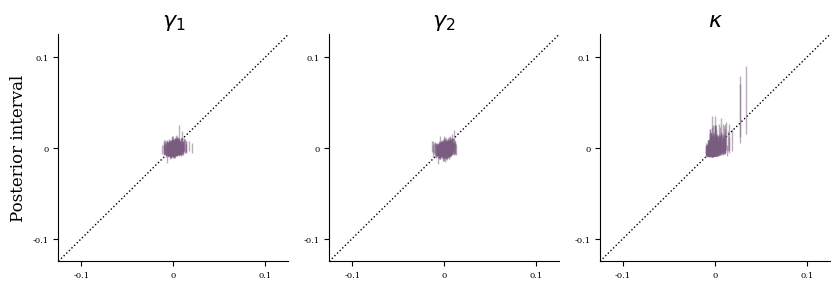

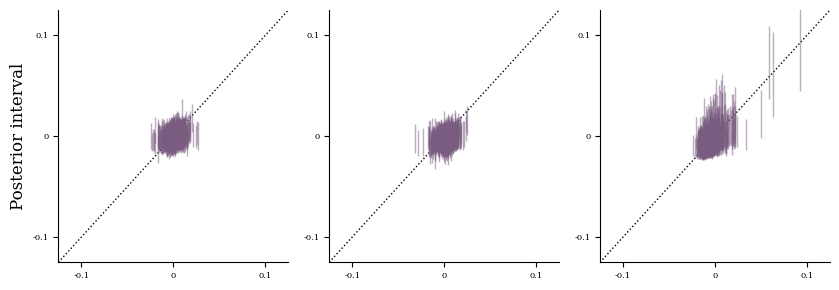

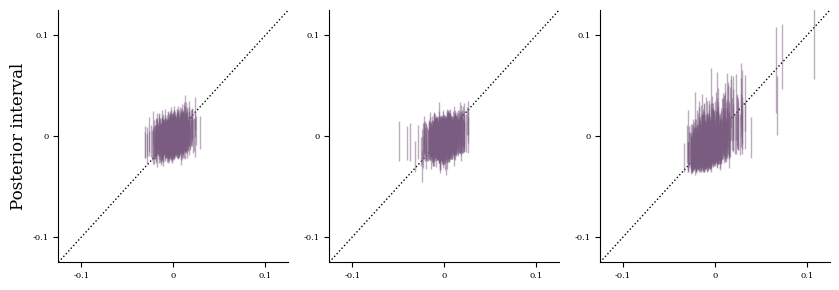

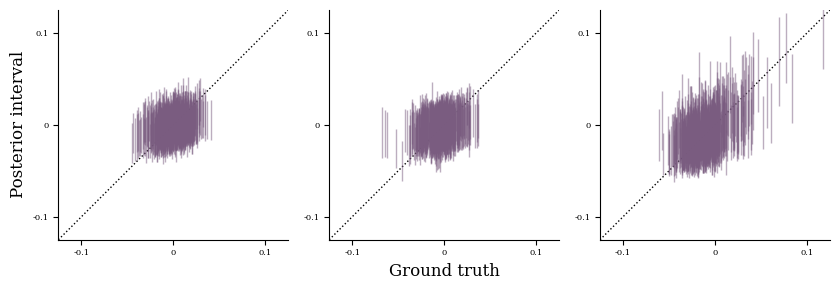

In [18]:
ci_fontsize = 12
ci_ticklabelsize = 6
ci_color = "#7a5c80"
ci_alpha = 0.5
ci_axmin = -0.125
ci_axmax = 0.125
interval_idx = 17  # 90% credible interval

np.random.seed(0)
indexes = np.random.choice(len(test_dl) * 64, 500, replace=False)

for b in range(num_bins):
    fig, ax = plt.subplots(1, 3, figsize=(8.5, 3))

    # Shear 1
    _ = ax[0].axline((0, 0), slope=1, linestyle="dotted", color="black", linewidth=1)
    for i in range(len(indexes)):
        _ = ax[0].vlines(
            x=fm_s1_true_flat[..., b].flatten(0, 1)[indexes[i]],
            ymin=fm_s1_ci_lower_flat[:, :, b, :].flatten(0, 1)[..., interval_idx][indexes[i]],
            ymax=fm_s1_ci_upper_flat[:, :, b, :].flatten(0, 1)[..., interval_idx][indexes[i]],
            alpha=ci_alpha, color=ci_color, linewidths=1,
        )

    # Shear 2
    _ = ax[1].axline((0, 0), slope=1, linestyle="dotted", color="black", linewidth=1)
    for i in range(len(indexes)):
        _ = ax[1].vlines(
            x=fm_s2_true_flat[..., b].flatten(0, 1)[indexes[i]],
            ymin=fm_s2_ci_lower_flat[:, :, b, :].flatten(0, 1)[..., interval_idx][indexes[i]],
            ymax=fm_s2_ci_upper_flat[:, :, b, :].flatten(0, 1)[..., interval_idx][indexes[i]],
            alpha=ci_alpha, color=ci_color, linewidths=1,
        )

    # Convergence
    _ = ax[2].axline((0, 0), slope=1, linestyle="dotted", color="black", linewidth=1)
    for i in range(len(indexes)):
        _ = ax[2].vlines(
            x=fm_k_true_flat[..., b].flatten(0, 1)[indexes[i]],
            ymin=fm_k_ci_lower_flat[:, :, b, :].flatten(0, 1)[..., interval_idx][indexes[i]],
            ymax=fm_k_ci_upper_flat[:, :, b, :].flatten(0, 1)[..., interval_idx][indexes[i]],
            alpha=ci_alpha, color=ci_color, linewidths=1,
        )

    if b == 0:
        _ = ax[0].set_title(r"$\gamma_1$", fontsize=16)
        _ = ax[1].set_title(r"$\gamma_2$", fontsize=16)
        _ = ax[2].set_title(r"$\kappa$", fontsize=16)

    if b == num_bins - 1:
        _ = ax[1].set_xlabel("Ground truth", fontsize=ci_fontsize)
    _ = ax[0].set_ylabel("Posterior interval", fontsize=ci_fontsize)

    for a in ax.flat:
        _ = a.spines[["top", "right"]].set_visible(False)
        _ = a.set_xlim(ci_axmin, ci_axmax)
        _ = a.set_ylim(ci_axmin, ci_axmax)
        _ = a.set_xticks([-0.1, 0, 0.1], [-0.1, 0, 0.1])
        _ = a.set_yticks([-0.1, 0, 0.1], [-0.1, 0, 0.1])
        _ = a.tick_params(axis="both", which="major", labelsize=ci_ticklabelsize)

    fig.tight_layout()
    fig.savefig(f"figures/credibleintervals_bin{b + 1}_fm.png", dpi=600, transparent=True, bbox_inches="tight", pad_inches=0)

## Nominal vs. Empirical Coverage (FM and NPE Overlaid)

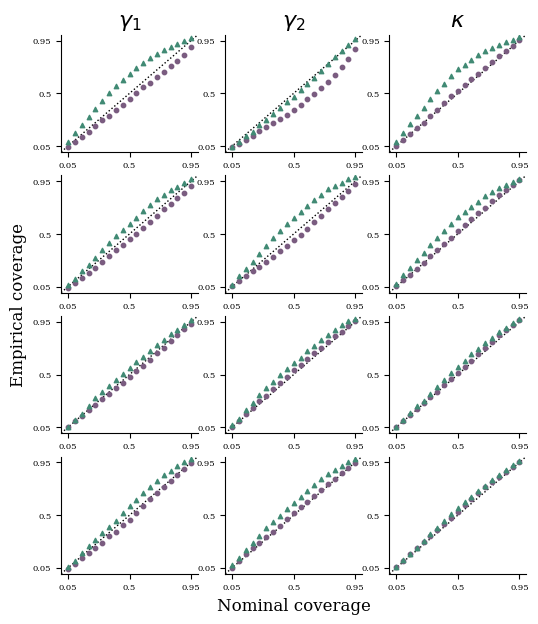

In [19]:
fig, ax = plt.subplots(num_bins, 3, figsize=(6, 7))

cov_fontsize = 12
cov_ticklabelsize = 6
fm_marker_color = "#7a5c80"
npe_marker_color = "#418a74"
cov_s = 10

for b in range(num_bins):
    # Shear 1
    _ = ax[b, 0].axline((0, 0), slope=1, linestyle="dotted", color="black", linewidth=1, zorder=0)
    _ = ax[b, 0].scatter(confidence_levels, fm_s1_coverage[:, b].cpu(), color=fm_marker_color, s=cov_s, zorder=1)
    _ = ax[b, 0].scatter(confidence_levels, npe_s1_coverage[b].cpu(), color=npe_marker_color, s=cov_s, zorder=1, marker="^")

    # Shear 2
    _ = ax[b, 1].axline((0, 0), slope=1, linestyle="dotted", color="black", linewidth=1, zorder=0)
    _ = ax[b, 1].scatter(confidence_levels, fm_s2_coverage[:, b].cpu(), color=fm_marker_color, s=cov_s, zorder=1)
    _ = ax[b, 1].scatter(confidence_levels, npe_s2_coverage[b].cpu(), color=npe_marker_color, s=cov_s, zorder=1, marker="^")

    # Convergence
    _ = ax[b, 2].axline((0, 0), slope=1, linestyle="dotted", color="black", linewidth=1, zorder=0)
    _ = ax[b, 2].scatter(confidence_levels, fm_k_coverage[:, b].cpu(), color=fm_marker_color, s=cov_s, zorder=1)
    _ = ax[b, 2].scatter(confidence_levels, npe_k_coverage[b].cpu(), color=npe_marker_color, s=cov_s, zorder=1, marker="^")

_ = ax[0, 0].set_title(r"$\gamma_1$", fontsize=16)
_ = ax[0, 1].set_title(r"$\gamma_2$", fontsize=16)
_ = ax[0, 2].set_title(r"$\kappa$", fontsize=16)
_ = ax[num_bins - 1, 1].set_xlabel("Nominal coverage", fontsize=cov_fontsize)
_ = ax[1, 0].set_ylabel("Empirical coverage", fontsize=cov_fontsize)
_ = ax[1, 0].yaxis.set_label_coords(-0.25, -0.1)

for a in ax.flat:
    _ = a.spines[["top", "right"]].set_visible(False)
    _ = a.set_xlim(0, 1)
    _ = a.set_ylim(0, 1)
    _ = a.set_xticks([0.05, 0.5, 0.95], [0.05, 0.5, 0.95])
    _ = a.set_yticks([0.05, 0.5, 0.95], [0.05, 0.5, 0.95])
    _ = a.tick_params(axis="both", which="major", labelsize=cov_ticklabelsize)

fig.savefig("figures/coverageprobs_fm_npe.png", dpi=600, transparent=True, bbox_inches="tight", pad_inches=0)